In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [6]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 훈련셋과 테스트셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from matplotlib import pyplot as plt # 학습과정 loss와 acc 시각화
# quiz에서는 scale조정, train_test_split 등을 추가

In [7]:
import numpy as np
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [9]:
print('타켓 :', data[1,0])
#print('이미지(28*28을 1차원으로) :', data[0, 1:].reshape(28,28))

타켓 : 0.0


In [10]:
for row in data[1, 1:].reshape(28,28):
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 51159253159 50  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 48238252252252237  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 54227253252239233252 57  6  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 10 60224252253252202 84252253122  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0163252252252253252252 96189253167  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0 51238253253190114253228 47 79255168  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 48238252252179 12 75121 21  0  0253243 50  0  0  0  0  0
  0  0  0  0  0  0  0  0 38165253233208 84  0  0  0  0  0  025325

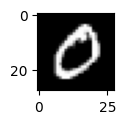

In [11]:
plt.figure(figsize=(1,1))
plt.imshow(data[1, 1:].reshape(28,28), cmap='gray')

In [12]:
# %pip install opencv-contrib-python

In [13]:
# %pip install opencv-python

In [16]:
# 칼라사진 -> 흑백모드의 넘파이 배열로
import cv2
image_gray = cv2.imread('C:/sample.jpg', cv2.IMREAD_GRAYSCALE) # 흑백포맷으로 읽기
print(image_gray.shape)
print(type(image_gray))

(588, 735)
<class 'numpy.ndarray'>


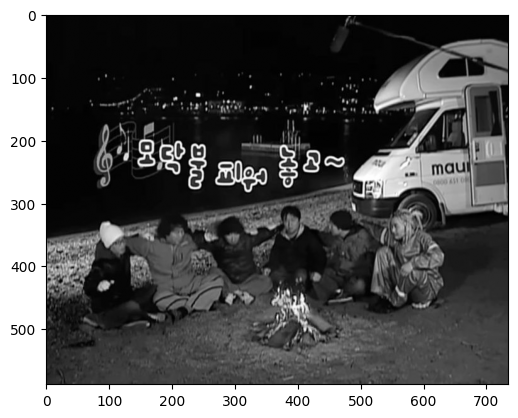

In [17]:
plt.imshow(image_gray, cmap='gray')

# 1. 데이터 생성 및 전처리

In [18]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

11490434/11490434 [==============================] - 2s 0us/step


((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [19]:
print(y_train[0])
for row in X_train[0]:
    for pixel in row:
        print('{:3.0f}'.format(pixel), end='')
    print()

5
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  3 18 18 18126136175 26166255247127  0  0  0  0
  0  0  0  0  0  0  0  0 30 36 94154170253253253253253225172253242195 64  0  0  0  0
  0  0  0  0  0  0  0 49238253253253253253253253253251 93 82 82 56 39  0  0  0  0  0
  0  0  0  0  0  0  0 18219253253253253253198182247241  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 80156107253253205 11  0 43154  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 14  1154253 90  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0139253190  2  0  0  0  0  0  0

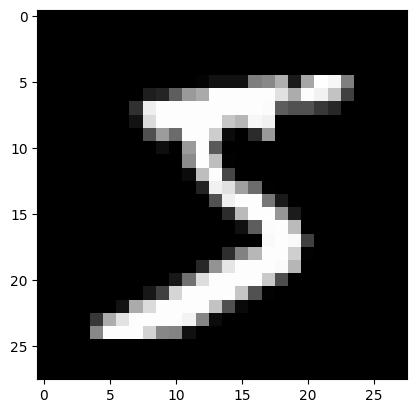

In [20]:
plt.imshow(X_train[0], cmap='gray')

In [21]:
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [22]:
# 학습셋(5만개:fit용), 검증셋(만:fit용), 테스트셋(만:평가용)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(50000, 28, 28) (50000,)
(10000, 28, 28) (10000,)
(10000, 28, 28) (10000,)


In [23]:
# 입력(독립)변수 (n, 28,28) -> (n, 784) -> 실수형변환 -> 스케일조정(255.0으로 나눠)
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [24]:
# 훈련셋5만개 -> 700개, 테스트셋1만개 -> 300개 추출(목적 : 학습시간 절약), 테스트셋은 그대로
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
train_X.shape, y_train.shape, val_X.shape, y_val.shape

((700, 784), (700,), (300, 784), (300,))

In [25]:
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
print(y_train[:2])
print(train_Y[:2])

[3 0]
[[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


# 2. 모델 구성

In [26]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 1570      
                                                                 
 dense_1 (Dense)             (None, 10)                30        
                                                                 
Total params: 1600 (6.25 KB)
Trainable params: 1600 (6.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# 3. 학습과정 설정

In [28]:
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])

# 4. 모델 학습

In [29]:
%%time
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y))

Epoch 1/500
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DEE9E7BAC0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DEE9E7BAC0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. 

7/7 [==============================] - 0s 12ms/step - loss: 1.7716 - accuracy: 0.4043 - val_loss: 1.9085 - val_accuracy: 0.3267
Epoch 36/500
7/7 [==============================] - 0s 15ms/step - loss: 1.7616 - accuracy: 0.4057 - val_loss: 1.9029 - val_accuracy: 0.3233
Epoch 37/500
7/7 [==============================] - 0s 14ms/step - loss: 1.7526 - accuracy: 0.4029 - val_loss: 1.8953 - val_accuracy: 0.3200
Epoch 38/500
7/7 [==============================] - 0s 14ms/step - loss: 1.7432 - accuracy: 0.4129 - val_loss: 1.8852 - val_accuracy: 0.3367
Epoch 39/500
7/7 [==============================] - 0s 12ms/step - loss: 1.7348 - accuracy: 0.4129 - val_loss: 1.8791 - val_accuracy: 0.3367
Epoch 40/500
7/7 [==============================] - 0s 11ms/step - loss: 1.7265 - accuracy: 0.4071 - val_loss: 1.8726 - val_accuracy: 0.3333
Epoch 41/500
7/7 [==============================] - 0s 12ms/step - loss: 1.7180 - accuracy: 0.3957 - val_loss: 1.8639 - val_accuracy: 0.3333
Epoch 42/500
7/7 [========

7/7 [==============================] - 0s 12ms/step - loss: 1.4304 - accuracy: 0.4657 - val_loss: 1.6101 - val_accuracy: 0.3700
Epoch 94/500
7/7 [==============================] - 0s 10ms/step - loss: 1.4270 - accuracy: 0.4643 - val_loss: 1.6081 - val_accuracy: 0.3667
Epoch 95/500
7/7 [==============================] - 0s 11ms/step - loss: 1.4233 - accuracy: 0.4700 - val_loss: 1.6058 - val_accuracy: 0.3700
Epoch 96/500
7/7 [==============================] - 0s 12ms/step - loss: 1.4198 - accuracy: 0.4700 - val_loss: 1.5997 - val_accuracy: 0.3667
Epoch 97/500
7/7 [==============================] - 0s 12ms/step - loss: 1.4160 - accuracy: 0.4743 - val_loss: 1.6016 - val_accuracy: 0.3700
Epoch 98/500
7/7 [==============================] - 0s 13ms/step - loss: 1.4117 - accuracy: 0.4743 - val_loss: 1.5975 - val_accuracy: 0.3700
Epoch 99/500
7/7 [==============================] - 0s 13ms/step - loss: 1.4080 - accuracy: 0.4700 - val_loss: 1.5946 - val_accuracy: 0.3733
Epoch 100/500
7/7 [=======

Epoch 151/500
7/7 [==============================] - 0s 12ms/step - loss: 1.2418 - accuracy: 0.5371 - val_loss: 1.4953 - val_accuracy: 0.4300
Epoch 152/500
7/7 [==============================] - 0s 12ms/step - loss: 1.2395 - accuracy: 0.5471 - val_loss: 1.4990 - val_accuracy: 0.4300
Epoch 153/500
7/7 [==============================] - 0s 13ms/step - loss: 1.2365 - accuracy: 0.5486 - val_loss: 1.4956 - val_accuracy: 0.4300
Epoch 154/500
7/7 [==============================] - 0s 13ms/step - loss: 1.2335 - accuracy: 0.5486 - val_loss: 1.4908 - val_accuracy: 0.4267
Epoch 155/500
7/7 [==============================] - 0s 13ms/step - loss: 1.2308 - accuracy: 0.5471 - val_loss: 1.4922 - val_accuracy: 0.4333
Epoch 156/500
7/7 [==============================] - 0s 14ms/step - loss: 1.2280 - accuracy: 0.5529 - val_loss: 1.4915 - val_accuracy: 0.4300
Epoch 157/500
7/7 [==============================] - 0s 14ms/step - loss: 1.2254 - accuracy: 0.5557 - val_loss: 1.4874 - val_accuracy: 0.4300
Epoch 

Epoch 209/500
7/7 [==============================] - 0s 10ms/step - loss: 1.1045 - accuracy: 0.6257 - val_loss: 1.4599 - val_accuracy: 0.4533
Epoch 210/500
7/7 [==============================] - 0s 10ms/step - loss: 1.1028 - accuracy: 0.6271 - val_loss: 1.4536 - val_accuracy: 0.4600
Epoch 211/500
7/7 [==============================] - 0s 10ms/step - loss: 1.1005 - accuracy: 0.6343 - val_loss: 1.4584 - val_accuracy: 0.4533
Epoch 212/500
7/7 [==============================] - 0s 10ms/step - loss: 1.0988 - accuracy: 0.6300 - val_loss: 1.4587 - val_accuracy: 0.4567
Epoch 213/500
7/7 [==============================] - 0s 10ms/step - loss: 1.0970 - accuracy: 0.6329 - val_loss: 1.4545 - val_accuracy: 0.4633
Epoch 214/500
7/7 [==============================] - 0s 9ms/step - loss: 1.0953 - accuracy: 0.6343 - val_loss: 1.4576 - val_accuracy: 0.4567
Epoch 215/500
7/7 [==============================] - 0s 10ms/step - loss: 1.0933 - accuracy: 0.6371 - val_loss: 1.4570 - val_accuracy: 0.4567
Epoch 2

Epoch 267/500
7/7 [==============================] - 0s 9ms/step - loss: 1.0123 - accuracy: 0.6671 - val_loss: 1.4644 - val_accuracy: 0.4867
Epoch 268/500
7/7 [==============================] - 0s 9ms/step - loss: 1.0109 - accuracy: 0.6657 - val_loss: 1.4600 - val_accuracy: 0.4833
Epoch 269/500
7/7 [==============================] - 0s 9ms/step - loss: 1.0094 - accuracy: 0.6714 - val_loss: 1.4665 - val_accuracy: 0.4867
Epoch 270/500
7/7 [==============================] - 0s 9ms/step - loss: 1.0080 - accuracy: 0.6657 - val_loss: 1.4638 - val_accuracy: 0.4867
Epoch 271/500
7/7 [==============================] - 0s 9ms/step - loss: 1.0066 - accuracy: 0.6686 - val_loss: 1.4675 - val_accuracy: 0.4867
Epoch 272/500
7/7 [==============================] - 0s 9ms/step - loss: 1.0054 - accuracy: 0.6686 - val_loss: 1.4652 - val_accuracy: 0.4967
Epoch 273/500
7/7 [==============================] - 0s 8ms/step - loss: 1.0038 - accuracy: 0.6671 - val_loss: 1.4686 - val_accuracy: 0.4933
Epoch 274/500

7/7 [==============================] - 0s 11ms/step - loss: 0.9425 - accuracy: 0.6929 - val_loss: 1.4959 - val_accuracy: 0.5067
Epoch 326/500
7/7 [==============================] - 0s 11ms/step - loss: 0.9411 - accuracy: 0.6943 - val_loss: 1.4901 - val_accuracy: 0.5100
Epoch 327/500
7/7 [==============================] - 0s 11ms/step - loss: 0.9401 - accuracy: 0.6957 - val_loss: 1.4964 - val_accuracy: 0.5033
Epoch 328/500
7/7 [==============================] - 0s 9ms/step - loss: 0.9392 - accuracy: 0.6943 - val_loss: 1.4970 - val_accuracy: 0.5033
Epoch 329/500
7/7 [==============================] - 0s 9ms/step - loss: 0.9382 - accuracy: 0.6914 - val_loss: 1.4948 - val_accuracy: 0.5067
Epoch 330/500
7/7 [==============================] - 0s 10ms/step - loss: 0.9372 - accuracy: 0.6971 - val_loss: 1.4961 - val_accuracy: 0.5033
Epoch 331/500
7/7 [==============================] - 0s 10ms/step - loss: 0.9363 - accuracy: 0.6943 - val_loss: 1.5014 - val_accuracy: 0.5033
Epoch 332/500
7/7 [===

Epoch 383/500
7/7 [==============================] - 0s 9ms/step - loss: 0.8876 - accuracy: 0.7200 - val_loss: 1.5455 - val_accuracy: 0.5000
Epoch 384/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8871 - accuracy: 0.7214 - val_loss: 1.5359 - val_accuracy: 0.5033
Epoch 385/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8851 - accuracy: 0.7214 - val_loss: 1.5509 - val_accuracy: 0.5067
Epoch 386/500
7/7 [==============================] - 0s 9ms/step - loss: 0.8855 - accuracy: 0.7157 - val_loss: 1.5518 - val_accuracy: 0.5033
Epoch 387/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8837 - accuracy: 0.7229 - val_loss: 1.5369 - val_accuracy: 0.5033
Epoch 388/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8829 - accuracy: 0.7243 - val_loss: 1.5456 - val_accuracy: 0.5033
Epoch 389/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8820 - accuracy: 0.7229 - val_loss: 1.5539 - val_accuracy: 0.5033
Epoch 390/500

Epoch 441/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8367 - accuracy: 0.7357 - val_loss: 1.5963 - val_accuracy: 0.5033
Epoch 442/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8365 - accuracy: 0.7329 - val_loss: 1.5963 - val_accuracy: 0.5100
Epoch 443/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8352 - accuracy: 0.7329 - val_loss: 1.5841 - val_accuracy: 0.5033
Epoch 444/500
7/7 [==============================] - 0s 8ms/step - loss: 0.8341 - accuracy: 0.7386 - val_loss: 1.5933 - val_accuracy: 0.5033
Epoch 445/500
7/7 [==============================] - 0s 11ms/step - loss: 0.8330 - accuracy: 0.7343 - val_loss: 1.5891 - val_accuracy: 0.5067
Epoch 446/500
7/7 [==============================] - 0s 9ms/step - loss: 0.8316 - accuracy: 0.7357 - val_loss: 1.5939 - val_accuracy: 0.5067
Epoch 447/500
7/7 [==============================] - 0s 9ms/step - loss: 0.8307 - accuracy: 0.7329 - val_loss: 1.5942 - val_accuracy: 0.5033
Epoch 448/50

Epoch 499/500
7/7 [==============================] - 0s 10ms/step - loss: 0.7897 - accuracy: 0.7600 - val_loss: 1.6232 - val_accuracy: 0.5233
Epoch 500/500
7/7 [==============================] - 0s 9ms/step - loss: 0.7887 - accuracy: 0.7571 - val_loss: 1.6258 - val_accuracy: 0.5233
CPU times: total: 48.7 s
Wall time: 37.9 s


# 5. 모델 평가하기

In [30]:
# 학습 과정 살펴보기
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

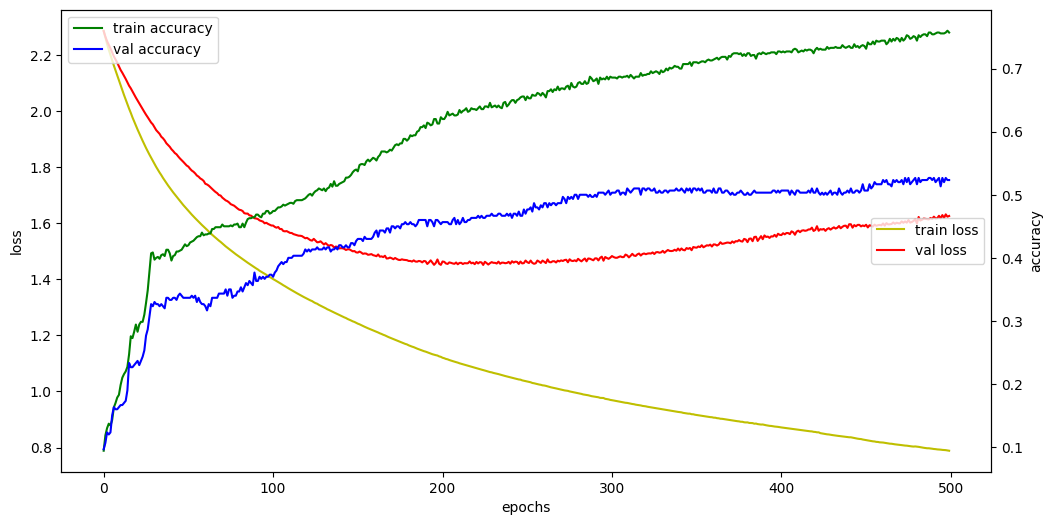

In [31]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [32]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

loss : 1.5778400897979736
accuracy : 0.5123999714851379


# ※ 위 모델(DNN)의 accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validation data추가, dropout, 활성화함수relu계열, tanh)
- epoch 조정
- optimizer 변경

Epoch 1/50
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DEEBA4C0D0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DEEBA4C0D0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. O

500/500 [==============================] - 13s 26ms/step - loss: 0.0185 - accuracy: 0.9948 - val_loss: 0.1303 - val_accuracy: 0.9836
Epoch 38/50
500/500 [==============================] - 13s 27ms/step - loss: 0.0189 - accuracy: 0.9950 - val_loss: 0.1126 - val_accuracy: 0.9850
Epoch 39/50
500/500 [==============================] - 14s 29ms/step - loss: 0.0203 - accuracy: 0.9945 - val_loss: 0.1343 - val_accuracy: 0.9831
Epoch 40/50
500/500 [==============================] - 13s 26ms/step - loss: 0.0253 - accuracy: 0.9937 - val_loss: 0.1240 - val_accuracy: 0.9828
Epoch 41/50
500/500 [==============================] - 13s 26ms/step - loss: 0.0222 - accuracy: 0.9944 - val_loss: 0.1190 - val_accuracy: 0.9822
Epoch 42/50
500/500 [==============================] - 13s 27ms/step - loss: 0.0234 - accuracy: 0.9938 - val_loss: 0.1209 - val_accuracy: 0.9820
Epoch 43/50
500/500 [==============================] - 13s 26ms/step - loss: 0.0197 - accuracy: 0.9949 - val_loss: 0.1094 - val_accuracy: 0.98

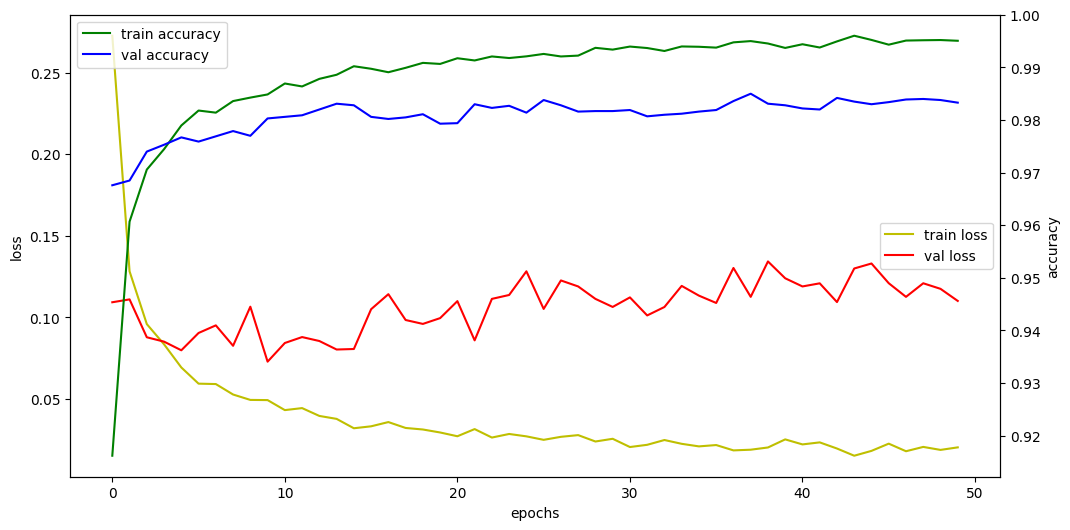

CPU times: total: 56min 37s
Wall time: 11min 2s


In [33]:
%%time
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000개 -> 700개 / 10000개 -> 300
# train_idx = np.random.choice(50000, 700)
# val_idx  = np.random.choice(10000, 300)
# train_X = train_X[train_idx]
# y_train = y_train[train_idx]
# val_X   = val_X[val_idx]
# y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=1024, activation='relu')) # tanh, relu, elu, gelu
model.add(Dropout(0.3))
model.add(Dense(units=512, activation='elu'))
model.add(Dropout(0.3))
model.add(Dense(units=256)) #  activation='leakyrelu'사용불가
from tensorflow.keras.layers import LeakyReLU
model.add(LeakyReLU(alpha=0.01)) 
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1)
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

In [34]:
# 모델 평가하기
loss_and_metrics = model.evaluate(test_X, test_Y, batch_size=100, verbose=0)
print('loss :', loss_and_metrics[0])
print('accuracy :', loss_and_metrics[1])

loss : 0.09549262374639511
accuracy : 0.9847999811172485


In [35]:
# 실제값
test_Y.argmax(axis=1) == y_test

array([ True,  True,  True, ...,  True,  True,  True])

In [36]:
# 예측값
yhat = model.predict(test_X).argmax(axis=1)
yhat = np.argmax(model.predict(test_X), axis=1)
yhat

Cause: Unable to locate the source code of <function Model.make_predict_function.<locals>.predict_function at 0x000002DEE9D5CF70>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_predict_function.<locals>.predict_function at 0x000002DEE9D5CF70>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Orig

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [37]:
pd.crosstab(y_test, yhat)

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,975,1,1,0,0,0,1,1,1,0
1,0,1129,3,1,0,0,1,0,1,0
2,1,0,1022,2,1,0,0,4,1,1
3,3,0,3,993,0,3,0,4,2,2
4,0,1,7,0,958,0,1,2,1,12
5,2,0,0,4,1,881,2,0,2,0
6,5,2,1,0,2,2,946,0,0,0
7,0,2,9,1,0,0,0,1006,2,8
8,5,2,4,1,3,3,0,2,949,5


In [41]:
from sklearn.metrics import confusion_matrix

In [42]:
confusion_matrix(y_test, yhat)

array([[ 975,    1,    1,    0,    0,    0,    1,    1,    1,    0],
       [   0, 1129,    3,    1,    0,    0,    1,    0,    1,    0],
       [   1,    0, 1022,    2,    1,    0,    0,    4,    1,    1],
       [   3,    0,    3,  993,    0,    3,    0,    4,    2,    2],
       [   0,    1,    7,    0,  958,    0,    1,    2,    1,   12],
       [   2,    0,    0,    4,    1,  881,    2,    0,    2,    0],
       [   5,    2,    1,    0,    2,    2,  946,    0,    0,    0],
       [   0,    2,    9,    1,    0,    0,    0, 1006,    2,    8],
       [   5,    2,    4,    1,    3,    3,    0,    2,  949,    5],
       [   2,    3,    0,    3,    4,    4,    0,    3,    1,  989]],
      dtype=int64)

In [43]:
# 틀린 갯수:
10000- 10000*loss_and_metrics[1]

152.00018882751465

In [44]:
cnt = 0
for y, h in zip(y_test, yhat):
    if y!=h:
        cnt += 1
print('틀린 갯수 :', cnt)

틀린 갯수 : 152


In [45]:
# 모델 저장
model.save('model/08_mnist.h5')

C:\Users\Admin\anaconda3\envs\tfenv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.


# ※ 콜백함수1 : 로그 출력

In [47]:
from keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [48]:
%%time
# 매번 로그 출력하면 지저분해 질 수 있으니, 특정 에포크마다 로그 출력하도록 제한
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}) : # 1 epoch마다 자동 실행되는 함수
        self.epoch += 1  # epoch마다 self.epoch값을 1씩 증가
        if self.epoch%10 == 0:
            print('epoch:{}, loss:{}, acc:{}, val_loss:{}, val_acc:{}'.\
                  format(self.epoch, 
                        logs.get('loss'),
                        logs.get('accuracy', '-'),
                        logs.get('val_loss', '-'),
                        logs.get('val_accuracy', '-')
                  )
            )
        
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# 학습셋(6만개) -> 훈련셋(5만개)+검증셋(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
train_X = X_train.reshape(50000, 784).astype('float32')/255.0
val_X   = X_val.reshape(10000, -1).astype('float32')/255.0
test_X = X_test.reshape(10000, -1).astype('float32')/255.0
# 50000개 -> 700개 / 10000개 -> 300
train_idx = np.random.choice(50000, 700)
val_idx  = np.random.choice(10000, 300)
train_X = train_X[train_idx]
y_train = y_train[train_idx]
val_X   = val_X[val_idx]
y_val   = y_val[val_idx]
# 타겟(종속)변수의 원핫인코딩
train_Y = to_categorical(y_train, 10)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape, test_X.shape, test_Y.shape
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
customHistory = CustomHistory()
hist = model.fit(train_X, train_Y,
                epochs=50,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=0,
                callbacks=[customHistory]) # 콜백함수

Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DE9DB3EA70>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DE9DB3EA70>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original err

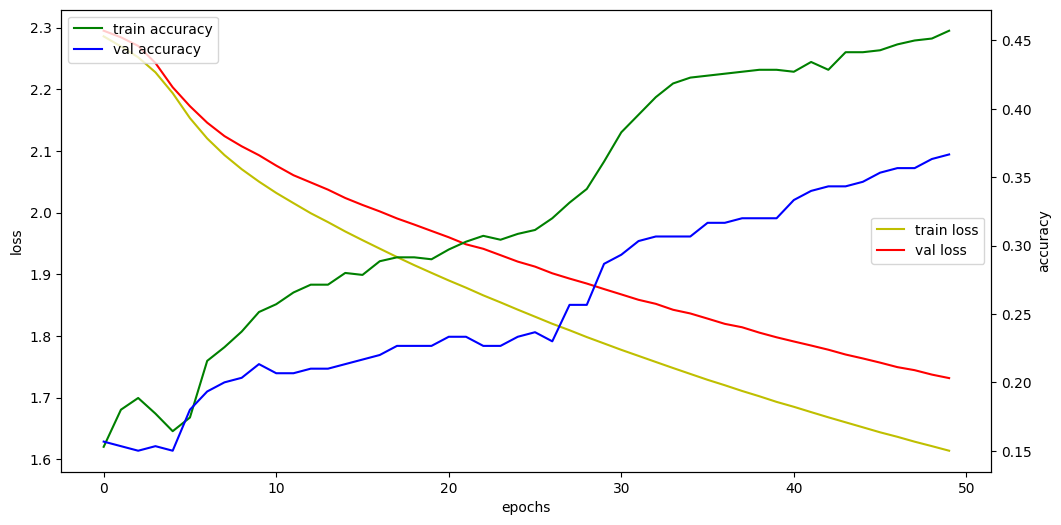

In [49]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(loc='center right')
acc_ax.legend()
plt.show()

# ※ 콜백함수2 : EarlyStopping
- val_loss값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 감소하면 지정한 epoch를 다 수행하지 않고 조기 종료

In [50]:
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
# monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=2) 
hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping]) # 콜백함수

Epoch 1/500
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DEEBD505E0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DEEBD505E0>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. 

# ※ 콜백함수3 : ModelCheckpoint
- epoch마다 val_accuracy(val_loss, accuracy, loss)값이 좋을 때 모델을 자동 저장하는 콜백

In [51]:
# 모델 생성
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
# 학습과정 설정
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='nadam',
             metrics=['accuracy'])
# 학습
# monitor기준으로 patience번 이상 안 좋은 데이터가 나오면 조기종료
earlystopping = EarlyStopping(monitor='val_accuracy', patience=10) 
# 모델 자동 저장 콜백
import os
model_save_folder = './model08/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'

checkpoint = ModelCheckpoint(filepath=file, 
                            monitor='val_accuracy', # 모리터할 지표
                            save_best_only=True, # 모니터링 지표가 개선된 경우만 저장
                            mode = 'max', # 값이 클수록 저장
                            verbose=1 # 저장시 로그 출력
                            )

hist = model.fit(train_X, train_Y,
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlystopping, checkpoint]) # 콜백함수

Epoch 1/500
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DE80B9C550>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. Original error: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: Unable to locate the source code of <function Model.make_train_function.<locals>.train_function at 0x000002DE80B9C550>. Note that functions defined in certain environments, like the interactive Python shell, do not expose their source code. If that is the case, you should define them in a .py source file. If you are certain the code is graph-compatible, wrap the call using @tf.autograph.experimental.do_not_convert. 

7/7 [==============================] - 0s 11ms/step - loss: 1.9341 - accuracy: 0.3029 - val_loss: 1.9284 - val_accuracy: 0.2833
Epoch 19/500
1/7 [===>..........................] - ETA: 0s - loss: 1.8918 - accuracy: 0.2700
Epoch 19: val_accuracy did not improve from 0.28333
7/7 [==============================] - 0s 9ms/step - loss: 1.9215 - accuracy: 0.3000 - val_loss: 1.9160 - val_accuracy: 0.2767
Epoch 20/500
1/7 [===>..........................] - ETA: 0s - loss: 1.9584 - accuracy: 0.2200
Epoch 20: val_accuracy improved from 0.28333 to 0.28667, saving model to ./model08\mnist-020-val0.2867.h5
7/7 [==============================] - 0s 11ms/step - loss: 1.9091 - accuracy: 0.3029 - val_loss: 1.9048 - val_accuracy: 0.2867
Epoch 21/500
1/7 [===>..........................] - ETA: 0s - loss: 1.9178 - accuracy: 0.3300
Epoch 21: val_accuracy improved from 0.28667 to 0.29000, saving model to ./model08\mnist-021-val0.2900.h5
7/7 [==============================] - 0s 11ms/step - loss: 1.8968 - ac

In [52]:
model.evaluate(val_X, val_Y)

10/10 [==============================] - 0s 3ms/step - loss: 1.7212 - accuracy: 0.3167


[1.7211536169052124, 0.3166666626930237]